# 10 — Behavioral Analysis: Tight Color Boxes, Then SuperAnimal Model

This approach uses video to estimate where the parrots are and track key body points (beak, head, feet, tail, and wing tips). I use DeepLabCut’s **SuperAnimal-Bird** model (`resnet_50` + `ssdlite`) without video adaptation.

For this first test, I used 4 short clips aligned to the onset and sampled at 10 fps. The birds are identified by their plumage color:

* `VID_20260710_150753` — green, Bird 4
* `VID_20260711_161458` / `161554` — purple Bird 2 + green Bird 5
* `VID_20260711_162245` — purple Bird 2 + green Bird 5 (wider window)

The original videos on the G drive are read-only. The short clips used here are in `dlc_demo/clips/`. Experimental images and videos are saved by version in `dlc_demo/versions/`. I use the **CHIRP DLC** kernel (`D:\CHIRP\.venv-dlc`), which has OpenCV and DeepLabCut installed.

| Version                            | What I did                                                                                                                                                                                              | Problem                                                                                                               |
| ---------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **v0** `v0_wholeframe_superanimal` | Ran SuperAnimal directly on the whole frame                                                                                                                                                             | The model often put the keypoints on the cage or background instead of the bird                                       |
| **v1** `v1_color_window_crop`      | Used a fixed plumage-color search window, cropped the window, and ran the model there                                                                                                                   | The perch and water bottle were still in the crop. The feet and tail of Birds 2 and 5 were usable, but Bird 4 was not |
| **v2** `v2_color_blob_tightbox`    | First found the olive-colored blob in the search window, made a tight box around the bird (including the head and feet), ran the model inside the box, and mapped the points back to the original frame | Current version. The color blobs are still unstable for `162245` and Bird 4                                           |

The code below runs the scripts in `dlc_demo/` in this order. Since SuperAnimal inference is pretty slow, I normally **do not rerun the model** and just use the images and tables that have already been generated.


In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

CHIRP = Path(r"D:\CHIRP")
DLC = CHIRP / "dlc_demo"
sys.path.insert(0, str(DLC))

from version_paths import V0, V1, V2
from color_blob import Blob, body_mask, load_hsv, load_windows, padded_box_from_blob, pick_blob_split

plt.rcParams["figure.dpi"] = 120

def show_bgr(paths, titles=None, cols=3):
    paths = [Path(p) for p in paths]
    titles = titles or [p.name for p in paths]
    n = len(paths)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.2 * rows))
    axes = [axes] if n == 1 else list(axes.ravel())
    for ax, path, title in zip(axes, paths, titles):
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

print("v0", V0.exists(), "v1", V1.exists(), "v2", V2.exists())

v0 True v1 True v2 True


## v0 — Full-Frame SuperAnimal

I first ran SuperAnimal on the full frame of the 8-second test clip `lovebirds_8s_10fps.mp4`, and then tried it once more on the same clip after cropping it. After that, I ran the model on the full length of two onset clips in `pilot_onset/`.

The model often placed the keypoints somewhere outside the bird, so I only kept this version as a comparison and did not use it for the actual trajectories.

The still frames I looked at when choosing the clips are in `preview_frames/`, and the thumbnail images I used for manual QC are in `qc_thumbs/`.


In [2]:
show_bgr(
    [
        V0 / "output" / "preview" / "labeled_1.jpg",
        V0 / "output_crop" / "preview" / "labeled_1.jpg",
        V0 / "qc_thumbs" / "VID_20260711_161458_lab1.jpg",
    ],
    ["v0 whole frame", "v0 cropped 8s", "QC thumb, pair"],
)

<Figure size 1512x384 with 3 Axes>

## v1 — Fixed Search Window, Then SuperAnimal

Each bird has a fixed perch search window (`color_windows.csv`). I cropped the whole window and resized it to 320 px wide (`v1/bird_crops/`), then ran SuperAnimal separately for each bird (`v1/dlc/`).

The thin outline is the **search window**, not a bounding box around the bird. The window also includes the green mineral perch and water bottle, which caused the model to fail on Bird 4.

Based on my manual QC on 2026-09-06, the feet and tail of Birds 2 and 5 were usable. For Bird 4, I only used the **centroid-based approach** and did not use its keypints.


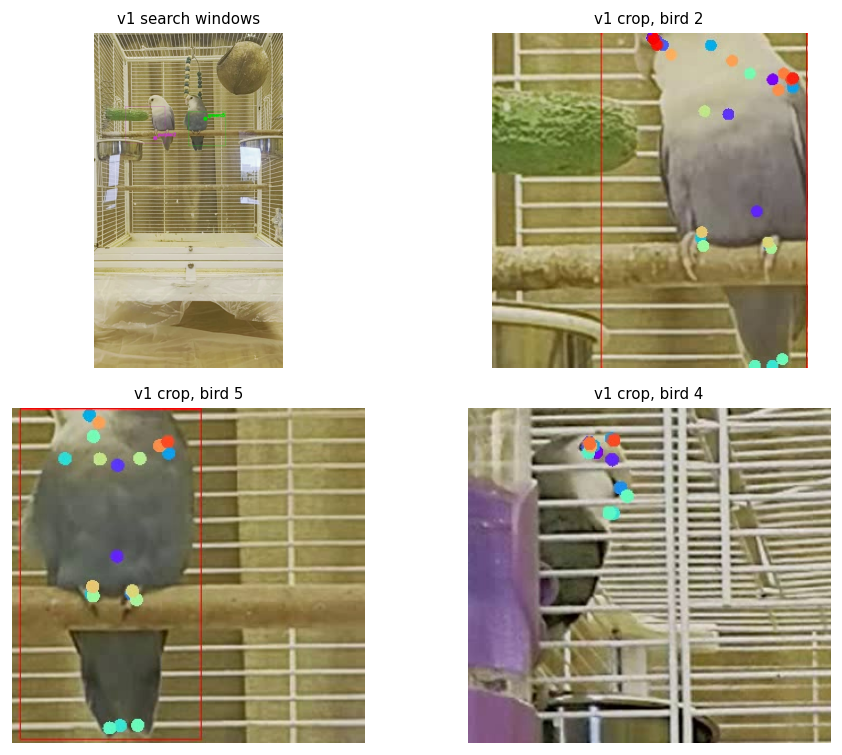

,video,receiver_id,composition,color_centroid,superanimal_parts,use_for,notes
0,VID_20260710_150753.mp4,4,solo_green,yes,no,MI_centroid_only,User QC 2026-09-06: SuperAnimal crop still fai...
1,VID_20260711_161458.mp4,2,purple_green,yes_with_drift,yes,MI_centroid_plus_parts,User QC 2026-09-06: crop SuperAnimal usable. P...
2,VID_20260711_161458.mp4,5,purple_green,yes,yes,MI_centroid_plus_parts,User QC 2026-09-06: crop SuperAnimal usable (f...


In [3]:
show_bgr(
    [
        V1 / "images" / "VID_20260711_161458_overlay_f060.jpg",
        V1 / "images" / "dlc_crop_VID_20260711_161458_purple_id2_f060.jpg",
        V1 / "images" / "dlc_crop_VID_20260711_161458_green_id5_f060.jpg",
        V1 / "images" / "dlc_crop_VID_20260710_150753_green_id4_f060.jpg",
    ],
    ["v1 search windows", "v1 crop, bird 2", "v1 crop, bird 5", "v1 crop, bird 4"],
    cols=2,
)
qc = pd.read_csv(DLC / "dlc_part_qc.csv")
qc

## v2 — Tight Box from Color Blob, Then SuperAnimal

1. In the search window, I used HSV to find the olive-colored body and remove the magenta toy (`color_blob.body_mask`).
2. Among the connected components, I picked the blob that was a reasonable size and aspect ratio for a bird and was also close to the bird’s position in the previous frame (`pick_blob_split`). When the color blob became too merged, I used erosion first.
3. I expanded the blob into a taller box so that it also included the white head and the feet hanging below (`padded_box_from_blob`). The box follows the bird instead of using the whole perch window.
4. For each frame, I resized this box to 256×256 (`make_tight_bird_crops.py`). Each bird was processed separately.
5. I ran SuperAnimal with `max_individuals=1` and `pcutoff=0.35` (`run_dlc_on_tight_crops.py`).
6. I mapped the crop coordinates back to the original frames and drew the tight box and the beak / crown / feet / tail / wing tips (`overlay_tight_dlc.py`)

The **in line** is still the search window, wle the **ick box** is the bird box sent to the model. I also tried several intermediate HSV settings (`images/trials/`), but did not use them in the finalversion.


[('purple', '2', (175, 221, 249, 404)), ('green', '5', (322, 184, 482, 394))]


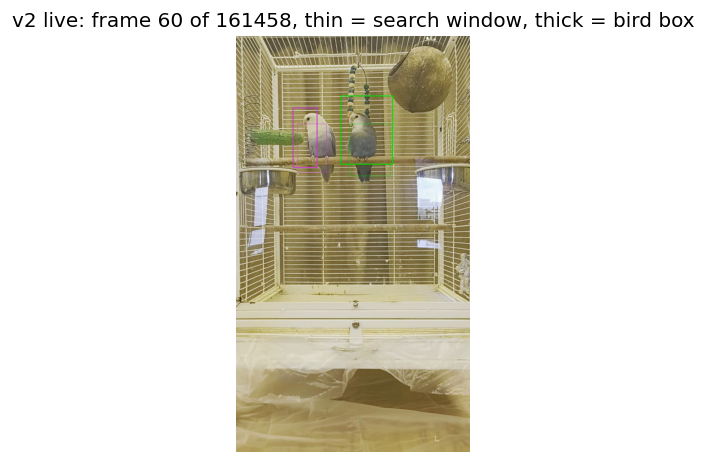

In [4]:
hsv = load_hsv()
windows = load_windows()
by_video = {}
for w in windows:
    by_video.setdefault(w["video"], []).append(w)

def boxes_on_frame(frame, wins):
    """One frame: olive blob -> tight box. Same functions the tracker uses."""
    vis = frame.copy()
    found = []
    for w in wins:
        x1, x2, y1, y2 = (int(w[k]) for k in ("x1", "x2", "y1", "y2"))
        crop = frame[y1:y2, x1:x2]
        hit = pick_blob_split(body_mask(crop, hsv), None, crop.shape[:2])
        if hit is None:
            found.append((w, None))
            continue
        full = Blob(hit.cx + x1, hit.cy + y1, hit.area, hit.x + x1, hit.y + y1, hit.w, hit.h)
        box = padded_box_from_blob(full, frame.shape[1], frame.shape[0])
        found.append((w, box))
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 220, 0) if w["track"] == "green" else (200, 60, 200), 1)
        cv2.rectangle(vis, (box[0], box[1]), (box[2], box[3]), (0, 220, 0) if w["track"] == "green" else (200, 60, 200), 2)
    return vis, found

clip = DLC / "clips" / "VID_20260711_161458_onset10fps.mp4"
cap = cv2.VideoCapture(str(clip))
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ok, frame = cap.read()
cap.release()
assert ok
vis, found = boxes_on_frame(frame, by_video["VID_20260711_161458.mp4"])
print([(w["track"], w["receiver_id"], box) for w, box in found])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title("v2 live: frame 60 of 161458, thin = search window, thick = bird box")
ax.axis("off")
plt.show()

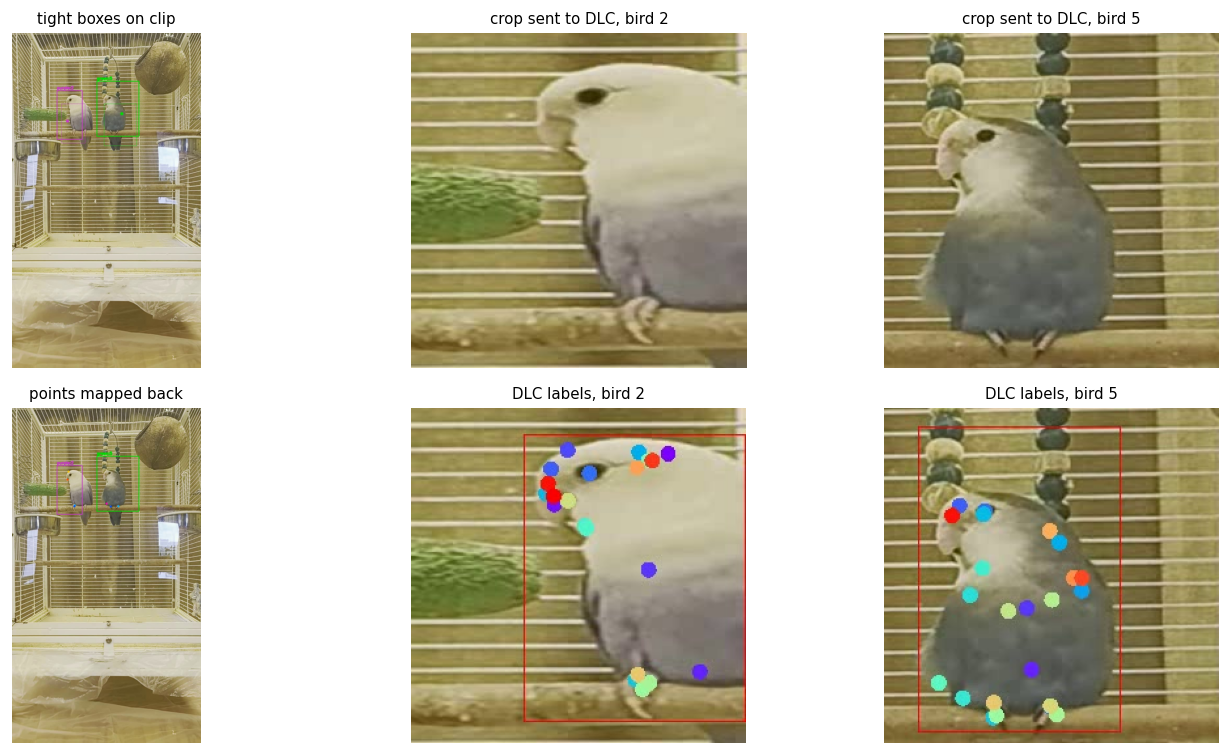

In [5]:
show_bgr(
    [
        V2 / "images" / "VID_20260711_161458_tight_f060.jpg",
        V2 / "images" / "tightcrop_VID_20260711_161458_purple_id2_f060.jpg",
        V2 / "images" / "tightcrop_VID_20260711_161458_green_id5_f060.jpg",
        V2 / "images" / "dlcover_VID_20260711_161458_colorbox_dlc_f060.jpg",
        V2 / "images" / "dlclab_VID_20260711_161458_purple_id2_f060.jpg",
        V2 / "images" / "dlclab_VID_20260711_161458_green_id5_f060.jpg",
    ],
    [
        "tight boxes on clip",
        "crop sent to DLC, bird 2",
        "crop sent to DLC, bird 5",
        "points mapped back",
        "DLC labels, bird 2",
        "DLC labels, bird 5",
    ],
    cols=3,
)

### Rerun (Off by Default)

The results are already saved in `versions/v2_color_blob_tightbox/`. Change the switches below to `True` if you want to rerun a step and overwrite the corresponding folder.

Color-blob tracking takes about a minute or two. SuperAnimal takes much longer when running on CPU.


In [6]:
RUN_TRACK = False
RUN_CROPS = False
RUN_DLC = False
RUN_OVERLAY = False

if RUN_TRACK:
    import color_track_pilots
    color_track_pilots.main()
if RUN_CROPS:
    import make_tight_bird_crops
    make_tight_bird_crops.main()
if RUN_DLC:
    import run_dlc_on_tight_crops
    run_dlc_on_tight_crops.main()
if RUN_OVERLAY:
    import overlay_tight_dlc
    overlay_tight_dlc.main()

print("track overlays", sorted(p.name for p in (V2 / "color_tracks").glob("*.mp4")))
print("tight crops", sorted(p.name for p in (V2 / "bird_crops").glob("*.mp4")))
print("dlc clips", sorted(p.name for p in (V2 / "dlc").glob("*")))
print("mapped overlays", sorted(p.name for p in (V2 / "overlays").glob("*.mp4")))

track overlays ['VID_20260710_150753_overlay.mp4', 'VID_20260711_161458_overlay.mp4', 'VID_20260711_161554_overlay.mp4', 'VID_20260711_162245_overlay.mp4']
tight crops ['VID_20260710_150753_green_id4.mp4', 'VID_20260711_161458_green_id5.mp4', 'VID_20260711_161458_purple_id2.mp4', 'VID_20260711_161554_green_id5.mp4', 'VID_20260711_161554_purple_id2.mp4', 'VID_20260711_162245_green_id5.mp4', 'VID_20260711_162245_purple_id2.mp4']
dlc clips ['VID_20260710_150753_green_id4', 'VID_20260711_161458_green_id5', 'VID_20260711_161458_purple_id2', 'VID_20260711_161554_green_id5', 'VID_20260711_161554_purple_id2', 'VID_20260711_162245_green_id5', 'VID_20260711_162245_purple_id2']
mapped overlays ['VID_20260710_150753_colorbox_dlc.mp4', 'VID_20260711_161458_colorbox_dlc.mp4', 'VID_20260711_161554_colorbox_dlc.mp4', 'VID_20260711_162245_colorbox_dlc.mp4']


### How Many Points Were Detected in This Version

In `dlc_tight_clipcoords.csv`, each body part is counted as a hit when its likelihood is ≥ 0.35. The movement of the color-blob centroid is recorded in `color_mi_pilot.csv` (starting around t ≥ 2 s after playback begins).

The color blobs for both birds in `161458` and `161554` were detected throughout the clips. The color blobs in `150753` (Bird 4) and `162245` often did not match the birds, so the keypoints from these two clare not real trajectories.e**.


In [7]:
pose = pd.read_csv(V2 / "dlc_tight_clipcoords.csv")
ok_cols = [c for c in pose.columns if c.endswith("_ok") and c != "n_parts_ok"]
hit = (
    pose.groupby(["video", "receiver_id", "track"], as_index=False)[ok_cols + ["n_parts_ok"]]
    .mean()
    .round(3)
)
mi = pd.read_csv(V2 / "color_mi_pilot.csv")
display(hit)
display(mi)

,video,receiver_id,track,bill_ok,crown_ok,left_foot_ok,right_foot_ok,tail_tip_ok,left_wing_tip_ok,right_wing_tip_ok,n_parts_ok
0,VID_20260710_150753.mp4,4,green,0.300,0.117,0.458,0.200,0.375,0.150,0.158,1.758
1,VID_20260711_161458.mp4,2,purple,0.717,1.000,0.900,0.875,0.425,0.158,0.142,4.217
2,VID_20260711_161458.mp4,5,green,0.758,0.967,0.983,0.983,0.975,0.000,0.000,4.667
3,VID_20260711_161554.mp4,2,purple,0.750,0.933,0.950,0.958,0.483,0.158,0.058,4.292
4,VID_20260711_161554.mp4,5,green,0.883,0.975,1.000,1.000,0.967,0.008,0.000,4.833
5,VID_20260711_162245.mp4,2,purple,0.433,0.350,0.067,0.075,0.692,0.258,0.192,2.067
6,VID_20260711_162245.mp4,5,green,0.400,0.275,0.375,0.333,0.533,0.100,0.050,2.067


,video,color,receiver_id,n_ok,frac_ok,MI_speed_mean,MI_speed_peak,body_diam_px,offset_s,MI_speed_median
0,VID_20260710_150753.mp4,green,4,0,0.00,NaN,NaN,NaN,10.00,NaN
1,VID_20260711_161458.mp4,purple,2,100,1.00,9.650,68.860,49.0,21.90,4.604
2,VID_20260711_161458.mp4,green,5,100,1.00,3.866,41.126,76.4,21.90,1.903
3,VID_20260711_161554.mp4,purple,2,100,1.00,11.750,158.973,41.5,33.75,3.689
4,VID_20260711_161554.mp4,green,5,100,1.00,4.118,25.118,79.5,33.75,2.200
5,VID_20260711_162245.mp4,purple,2,0,0.00,NaN,NaN,NaN,18.40,NaN
6,VID_20260711_162245.mp4,green,5,3,0.03,0.000,0.000,0.0,18.40,0.000
